In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.lines as mlines
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Data Access
All data is stored on **Google Drive**. We mount the drive and import the required datasets directly into the environment.

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/click count/cleared_analyzed_data.csv')

df.head()

,date,file,name,clicks
0,2025-08-06,IMG-20250806-WA0003.jpg,Ahmad3,149
1,2025-08-03,IMG-20250803-WA0007.jpg,Ahmada,254
2,2025-08-06,IMG-20250806-WA0003.jpg,Ahmada,202
3,2025-08-03,IMG-20250803-WA0007.jpg,Ahmadg,37
4,2026-01-08,IMG-20260108-WA0006.jpg,Alexander3,312


### Data Structure
The dataset is presented in a tabular format and consists of the following fields:

*   **date:** The file creation date extracted from the filename.
*   **file:** The name of the original image from which the data was parsed.
*   **name:** The employee's name as recorded in the system.
*   **clicks:** The total number of barcode scans performed by the employee on that specific day.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2655 entries, 0 to 2654
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   date    2655 non-null   object
 1   file    2655 non-null   object
 2   name    2655 non-null   object
 3   clicks  2655 non-null   int64 
dtypes: int64(1), object(3)
memory usage: 83.1+ KB


В файле 2655 строк.

In [ ]:
sorted = df['name'].unique()
sorted

array(['Ahmad3', 'Ahmada', 'Ahmadg', 'Alexander3', 'Amina', 'Amir3',
       'ANAN', 'Angelikas', 'Arago', 'Arego', 'Arkady3', 'ArtiomB',
       'Ayub', 'Baruch', 'baruchk', 'Ben', 'PHATHARAPHON3', 'Boleslav',
       'bushra', 'Daniel', 'DanielL', 'DavidSch', 'dimap', 'Dimav',
       'DimaV', 'Eyob', 'Fernando', 'Gosha', 'hadash6', 'Haim', 'Idank',
       'IdoA', 'Igor3', 'Iraa', 'Itzhak3', 'Kirills', 'Kosta3',
       'Kostantin3', 'YuliaV', 'Leonid3', 'Liera', 'Lior3', 'liran',
       'Vladimir3', 'marat', 'maratw', 'Mohamad3', 'Nabaa6', 'nadims',
       'Naor', 'OlgaA', 'Olgak', 'Oran', 'Oshri3', 'PAITOON3',
       'PATTAVEE3', 'peter3', 'PHANTASAK3', 'PHATTHAMA3', 'PHATTHANA3',
       'Phillip', 'Rami3', 'Refael3', 'Roman3', 'samuil3', 'Sanad3',
       'SATIT3', 'SAVA3', 'Shay', 'SOMSAK3', 'SQUSAK3', 'vladi',
       'Vladimira', 'WANCHALERM3', 'Wiaam', 'WORAWUT3', 'Yacov', 'yuliaK'],
      dtype=object)

### Employee Verification
We verify unique entries in the **name** field. Each unique entry represents an individual employee identified by the system.

### Identifying and Filtering Latest Daily Data Versions

Since multiple snapshots were taken throughout a single day, and only the final one contains the most up-to-date cumulative data, additional transformations are required.

To achieve this, we will perform the following steps:
1.  **Date Conversion:** Convert the `date` column to a standard `datetime` format for efficient time-series manipulation.
2.  **Sequence Extraction:** Extract the numeric sequence number from the filenames (e.g., extracting `0003` from `IMG-20250806-WA0003.jpg`). This number serves as a version indicator.
3.  **Snapshot Identification:** For each unique date, identify the row corresponding to the file with the maximum sequence number. These rows will be marked as `True` in a new column named `is_latest_daily_version`.
4.  **Data Filtering:** Create a new DataFrame, `df_latest_daily_version`, containing only the rows flagged as `True` (the final/latest data version for each day).

In [ ]:
# @title
# 1. Преобразуем столбец 'date' в формат datetime
df['date'] = pd.to_datetime(df['date'])

# 2. Извлекаем порядковый номер из имени файла для определения "версии"
# Например, из 'IMG-20250806-WA0003.jpg' извлекаем '0003' и преобразуем в число 3.
# Это временный столбец, который поможет нам определить самую последнюю версию.
df['file_sequence'] = df['file'].str.extract(r'WA(\d+)\.jpg').astype(int)

# 3. Для каждой даты находим максимальный порядковый номер файла.
# Используем transform('max'), чтобы применить это значение ко всем строкам в каждой группе.
max_sequence_per_date = df.groupby('date')['file_sequence'].transform('max')

# 4. Создаем новый столбец 'is_latest_daily_version' в исходном DataFrame 'df'.
# Он будет содержать True для всех строк, чей 'file_sequence' соответствует максимальному для их даты.
df['is_latest_daily_version'] = (df['file_sequence'] == max_sequence_per_date)

# 5. Создаем новый DataFrame, содержащий только записи "последней версии" для каждого дня.
# Это соответствует запросу "оставить только актуальные".
df_latest_daily_version = df[df['is_latest_daily_version']].copy()

# Удаляем временный столбец 'file_sequence' из обоих DataFrame, так как он больше не нужен
df.drop(columns=['file_sequence'], inplace=True)
df_latest_daily_version.drop(columns=['file_sequence'], inplace=True)

# Отображаем первые несколько строк исходного DataFrame с новым параметром
print("DataFrame с добавленным параметром 'is_latest_daily_version':")
display(df.head())

# Отображаем первые несколько строк нового DataFrame, отфильтрованного по последним версиям дня
print("\nDataFrame, отфильтрованный по последним версиям дня:")
display(df_latest_daily_version.head())

DataFrame с добавленным параметром 'is_latest_daily_version':


,date,file,name,clicks,is_latest_daily_version
0,2025-08-06,IMG-20250806-WA0003.jpg,Ahmad3,149,True
1,2025-08-03,IMG-20250803-WA0007.jpg,Ahmada,254,True
2,2025-08-06,IMG-20250806-WA0003.jpg,Ahmada,202,True
3,2025-08-03,IMG-20250803-WA0007.jpg,Ahmadg,37,True
4,2026-01-08,IMG-20260108-WA0006.jpg,Alexander3,312,True



DataFrame, отфильтрованный по последним версиям дня:


,date,file,name,clicks,is_latest_daily_version
0,2025-08-06,IMG-20250806-WA0003.jpg,Ahmad3,149,True
1,2025-08-03,IMG-20250803-WA0007.jpg,Ahmada,254,True
2,2025-08-06,IMG-20250806-WA0003.jpg,Ahmada,202,True
3,2025-08-03,IMG-20250803-WA0007.jpg,Ahmadg,37,True
4,2026-01-08,IMG-20260108-WA0006.jpg,Alexander3,312,True


In [ ]:
df_latest_daily_version.sort_values(by='date', ascending=False).head(30)

,date,file,name,clicks,is_latest_daily_version
1155,2026-04-09,IMG-20260409-WA0000.jpg,maratw,5,True
2175,2026-04-09,IMG-20260409-WA0000.jpg,SOMSAK3,235,True
1903,2026-04-09,IMG-20260409-WA0000.jpg,SATIT3,243,True
2470,2026-04-09,IMG-20260409-WA0000.jpg,WORAWUT3,190,True
1528,2026-04-09,IMG-20260409-WA0000.jpg,PHANTASAK3,251,True
772,2026-04-09,IMG-20260409-WA0000.jpg,Dimav,286,True
850,2026-04-09,IMG-20260409-WA0000.jpg,Fernando,257,True
2118,2026-04-09,IMG-20260409-WA0000.jpg,Shay,193,True
57,2026-04-09,IMG-20260409-WA0000.jpg,ANAN,278,True
1818,2026-04-09,IMG-20260409-WA0000.jpg,Roman3,239,True


In [ ]:
# @title
# Фильтруем данные за 2026 год
df_2026 = df_latest_daily_version[df_latest_daily_version['date'].dt.year == 2026].copy()

# Извлекаем месяц и день из столбца 'date'
df_2026['month'] = df_2026['date'].dt.month
df_2026['day'] = df_2026['date'].dt.day

# Группируем по месяцам и считаем количество уникальных дней
working_days_per_month = df_2026.groupby('month')['day'].nunique().reset_index()
working_days_per_month.rename(columns={'day': 'num_working_days'}, inplace=True)

# Добавляем названия месяцев для лучшей читаемости
working_days_per_month['month_name'] = working_days_per_month['month'].apply(lambda x: pd.to_datetime(str(x), format='%m').strftime('%B'))

print("Количество рабочих дней по месяцам (2026 год):")
display(working_days_per_month)

Количество рабочих дней по месяцам (2026 год):


,month,num_working_days,month_name
0,1,16,January
1,2,19,February
2,3,14,March
3,4,3,April


### 1. Full Timeline Performance

A complete historical overview of 'Roman3' click activity from the beginning of data collection: **July 2025 to April 2026**. The **Baseline** represents the minimum required daily click count (350 clicks).


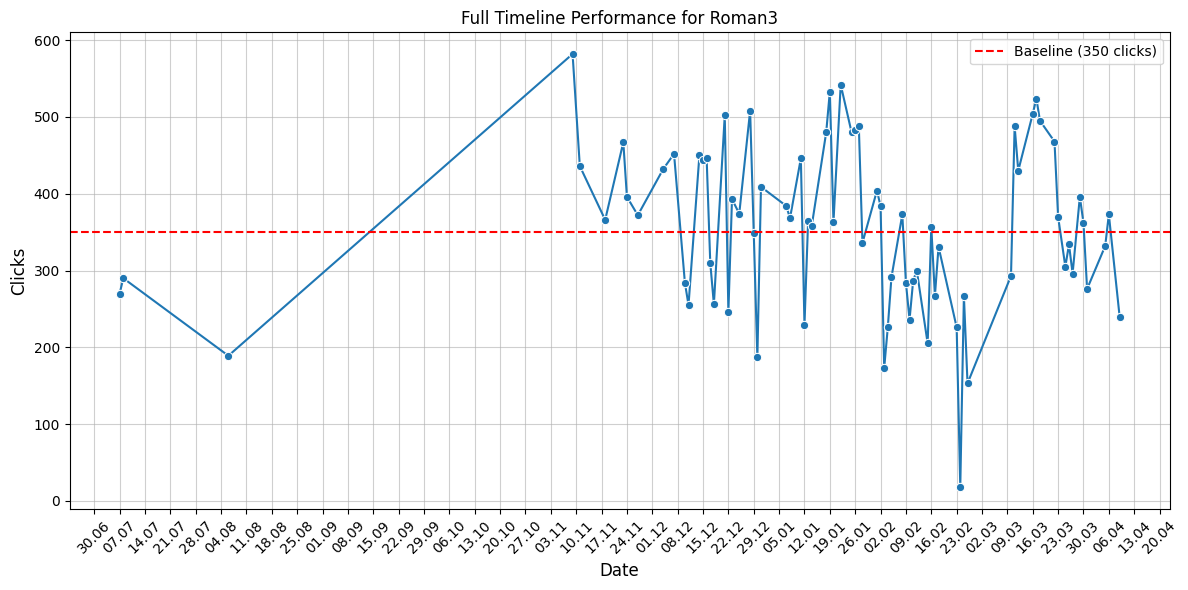

In [ ]:
# Фильтруем данные для имени 'Roman3' из df_latest_daily_version
roman3_df = df_latest_daily_version[df_latest_daily_version['name'] == 'Roman3'].sort_values(by='date')

# Проверяем, есть ли данные для 'Roman3'
if not roman3_df.empty:
    plt.figure(figsize=(12, 6))
    sns.lineplot(x='date', y='clicks', data=roman3_df, marker='o')
    # --- ЕДИНЫЙ ФОРМАТ СЕТКИ ---
    # Основная сетка: Каждые 7 дней (Понедельники)
    plt.gca().xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO, interval=1))
    # Формат даты: День.Месяц (например 01.12)
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d.%m'))

    # Добавляем горизонтальную линию на уровне 350 кликов
    plt.axhline(y=350, color='r', linestyle='--', label='Baseline (350 clicks)')

    plt.title('Full Timeline Performance for Roman3')
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Clicks', fontsize=12)
    # Делаем сетку более аккуратной
    plt.grid(True, which='major', linestyle='-', alpha=0.6)
    plt.grid(True, which='minor', linestyle=':', alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.legend()
    plt.show()
else:
    print("Данных для имени 'Roman3' не найдено в отфильтрованном DataFrame.")

### 2. Focused Performance Analysis (Dec 2025 – April 2026)


Filtered view starting from December 2025 to ensure data density and better representativeness for current performance evaluation.

Additionally, a vertical line is added at **March 22, 2026**, marking the date 'Roman3' officially joined **Golf**.

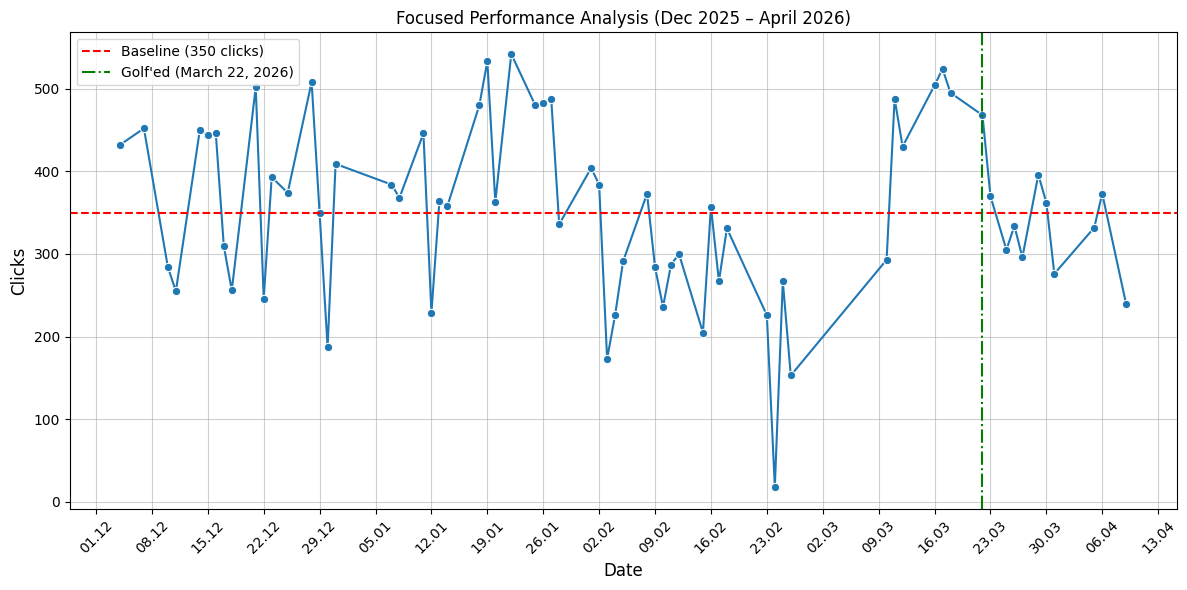

In [ ]:
# Фильтруем данные для имени 'Roman3' из df_latest_daily_version
roman3_df = df_latest_daily_version[
    (df_latest_daily_version['name'] == 'Roman3') &
    (df_latest_daily_version['date'] >= '2025-12-01')
].sort_values(by='date')

# Проверяем, есть ли данные для 'Roman3'
if not roman3_df.empty:
    plt.figure(figsize=(12, 6))
    sns.lineplot(x='date', y='clicks', data=roman3_df, marker='o') # Добавляем маркеры для каждой точки

    # --- ЕДИНЫЙ ФОРМАТ СЕТКИ ---
    # Основная сетка: Каждые 7 дней (Понедельники)
    plt.gca().xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO, interval=1))
    # Формат даты: День.Месяц
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d.%m'))

    # Добавляем горизонтальную линию на уровне 350 кликов
    plt.axhline(y=350, color='r', linestyle='--', label='Baseline (350 clicks)')

    # Добавляем вертикальную линию на 22 марта 2026 года
    plt.axvline(x=pd.to_datetime('2026-03-22'), color='g', linestyle='-.', label="Golf'ed (March 22, 2026)")

    plt.title('Focused Performance Analysis (Dec 2025 – April 2026)')
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Clicks', fontsize=12)

    # Делаем сетку более аккуратной (согласно новому стандарту)
    plt.grid(True, which='major', linestyle='-', alpha=0.6)
    plt.grid(True, which='minor', linestyle=':', alpha=0.3)

    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Данных для имени 'Roman3' за указанный период не найдено.")

### 3. Peer Benchmarking: 'Roman3' vs. Key Staff

Comparative analysis of 'Roman3' against selected colleagues ('DimaV', 'ArtiomB', 'Fernando') to establish relative performance levels. These employees were selected randomly for benchmarking purposes.

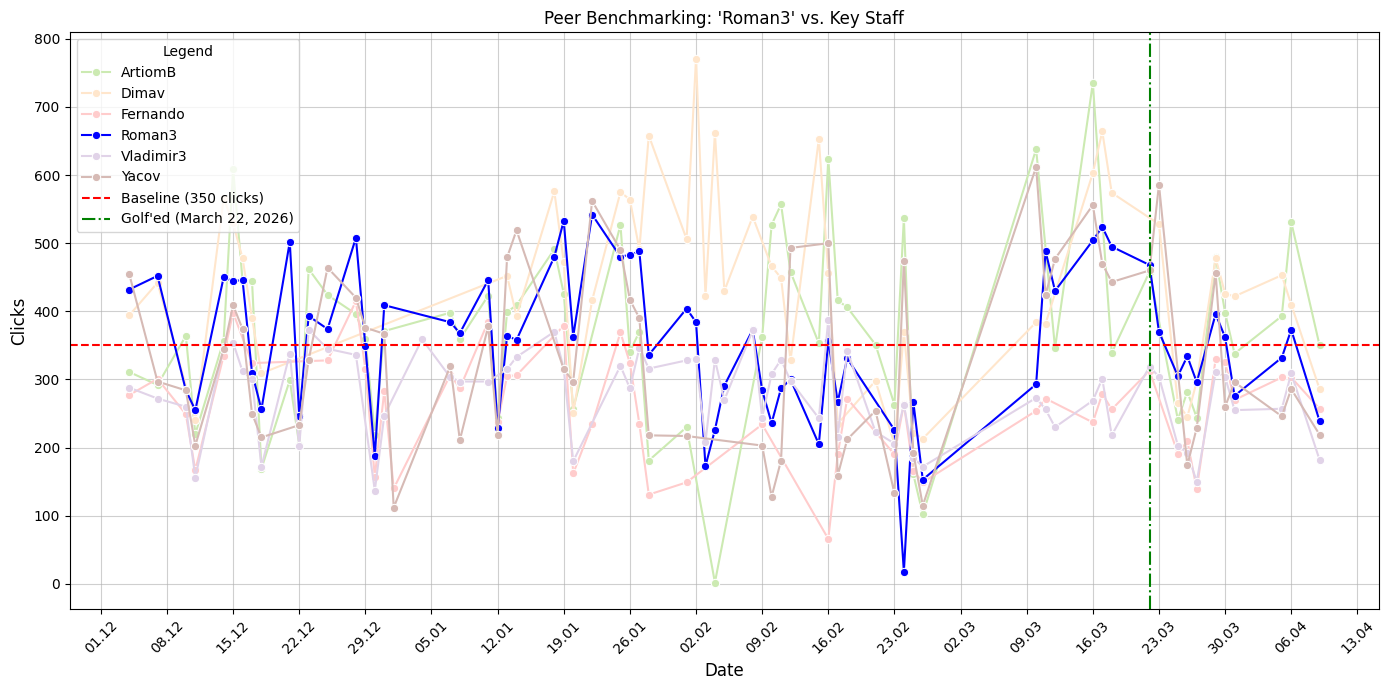

In [ ]:
# Define the list of names to plot
names_to_plot = ['Roman3', 'Dimav', 'ArtiomB', 'Fernando', 'Vladimir3', 'Yacov']

# Define a custom color palette with 'Roman3' in blue
custom_palette = {
    'Roman3': 'blue',      # Насыщенный синий (Royal Blue)
    'Dimav': '#ffe6cc',       # Светло-оранжевый (Pale Orange)
    'ArtiomB': '#cceab2',     # Светло-зеленый (Pale Green)
    'Fernando': '#ffcccc',    # Светло-красный (Soft Red/Pink)
    'Vladimir3': '#e1d3e8',   # Светло-фиолетовый (Pale Purple)
    'Yacov': '#d6bab5'        # Светло-коричневый (Pale Brown)
}

# Filter data for the specified names and period from df_latest_daily_version
multi_name_df = df_latest_daily_version[
    (df_latest_daily_version['name'].isin(names_to_plot)) &
    (df_latest_daily_version['date'] >= '2025-12-01')
].sort_values(by=['name', 'date'])

# Check if there is data for any of the names
if not multi_name_df.empty:
    plt.figure(figsize=(14, 7))
    sns.lineplot(x='date', y='clicks', hue='name', data=multi_name_df, marker='o', palette=custom_palette)

    # --- ЕДИНЫЙ ФОРМАТ СЕТКИ ---
    # Основная сетка: Каждые 7 дней (Понедельники)
    plt.gca().xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO, interval=1))
    # Формат даты: День.Месяц
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d.%m'))

    # Add horizontal line at 350 clicks
    plt.axhline(y=350, color='r', linestyle='--', label='Baseline (350 clicks)')

    # Add vertical line on March 22, 2026
    plt.axvline(x=pd.to_datetime('2026-03-22'), color='g', linestyle='-.', label="Golf'ed (March 22, 2026)")

    plt.title("Peer Benchmarking: 'Roman3' vs. Key Staff")
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Clicks', fontsize=12)

    # Делаем сетку более аккуратной
    plt.grid(True, which='major', linestyle='-', alpha=0.6)
    plt.grid(True, which='minor', linestyle=':', alpha=0.3)

    plt.xticks(rotation=45)
    plt.legend(title='Legend')
    plt.tight_layout()
    plt.show()
else:
    print("Данных для указанных имен за выбранный период не найдено.")

### 4. Contextual Impact: SABON Launch & Geopolitical Events

Correlation between workload and external factors. This visualization highlights how specialized assignments (SABON) and regional instability (EPIC FURRY) influenced output.


*   **SABON:** Represents the period when **'Roman3'** was assigned to a newly launched department. Working in this department required significantly more focus, precision, and effort compared to standard operations.
*   **EPIC FURRY:** Marks the onset of active military operations in Israel and the USA against Iran. This geopolitical event had a substantial impact on overall business logistics and operations.

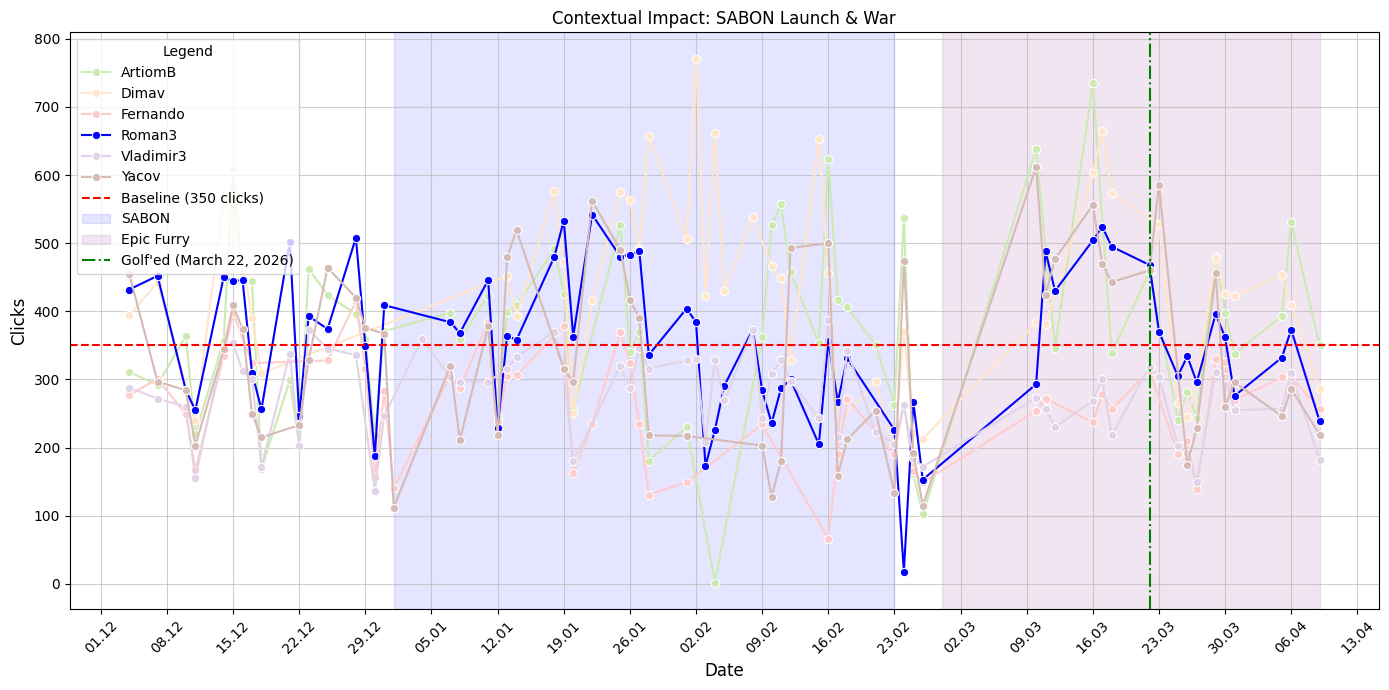

In [ ]:
# Define the list of names to plot
names_to_plot = ['Roman3', 'Dimav', 'ArtiomB', 'Fernando', 'Vladimir3', 'Yacov']

# Define a custom color palette with 'Roman3' in blue
custom_palette = {
    'Roman3': 'blue',      # Насыщенный синий (Royal Blue)
    'Dimav': '#ffe6cc',       # Светло-оранжевый (Pale Orange)
    'ArtiomB': '#cceab2',     # Светло-зеленый (Pale Green)
    'Fernando': '#ffcccc',    # Светло-красный (Soft Red/Pink)
    'Vladimir3': '#e1d3e8',   # Светло-фиолетовый (Pale Purple)
    'Yacov': '#d6bab5'        # Светло-коричневый (Pale Brown)
}

# Filter data for the specified names and period from df_latest_daily_version
multi_name_df = df_latest_daily_version[
    (df_latest_daily_version['name'].isin(names_to_plot)) &
    (df_latest_daily_version['date'] >= '2025-12-01')
].sort_values(by=['name', 'date'])

# Check if there is data for any of the names
if not multi_name_df.empty:
    plt.figure(figsize=(14, 7))
    sns.lineplot(x='date', y='clicks', hue='name', data=multi_name_df, marker='o', palette=custom_palette)

    # --- ЕДИНЫЙ ФОРМАТ СЕТКИ ---
    # Основная сетка: Каждые 7 дней (Понедельники)
    plt.gca().xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO, interval=1))
    # Формат даты: День.Месяц
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d.%m'))

    # Add horizontal line at 350 clicks
    plt.axhline(y=350, color='r', linestyle='--', label='Baseline (350 clicks)')
    # Add two periods to the graph
    # SABON period: January 1st to February 23rd, 2026
    plt.axvspan(pd.to_datetime('2026-01-01'), pd.to_datetime('2026-02-23'), color='blue', alpha=0.1, label='SABON')
    # Epic Furry period: February 28th, 2026 to the latest date in the data
    plt.axvspan(pd.to_datetime('2026-02-28'), multi_name_df['date'].max(), color='purple', alpha=0.1, label='Epic Furry')


    # Add vertical line on March 22, 2026
    plt.axvline(x=pd.to_datetime('2026-03-22'), color='g', linestyle='-.', label="Golf'ed (March 22, 2026)")

    plt.title("Contextual Impact: SABON Launch & War")
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Clicks', fontsize=12)

    # Делаем сетку более аккуратной
    plt.grid(True, which='major', linestyle='-', alpha=0.6)
    plt.grid(True, which='minor', linestyle=':', alpha=0.3)

    plt.xticks(rotation=45)
    plt.legend(title='Legend')
    plt.tight_layout()
    plt.show()
else:
    print("Данных для указанных имен за выбранный период не найдено.")

### 5. Comparative Efficiency: 'Roman3' vs. New Onboarders (Thai Staff)

Description: Benchmarking 'Roman3' against the newly joined staff from Thailand to evaluate the efficiency of an experienced employee versus new arrivals.



In [ ]:
# @title
thai_names = [
    'PHATHRAPHON3',
    'WANCHALERM3',
    'PAITOON3',
    'PHANTASAK3',
    'SATIT3',
    'WORAWUT3',
    'PATTAVEE3',
    'SOMSAK3',
    'PHATTHANA3'
]
print("Переменная 'thai_names' создана.")

Переменная 'thai_names' создана.


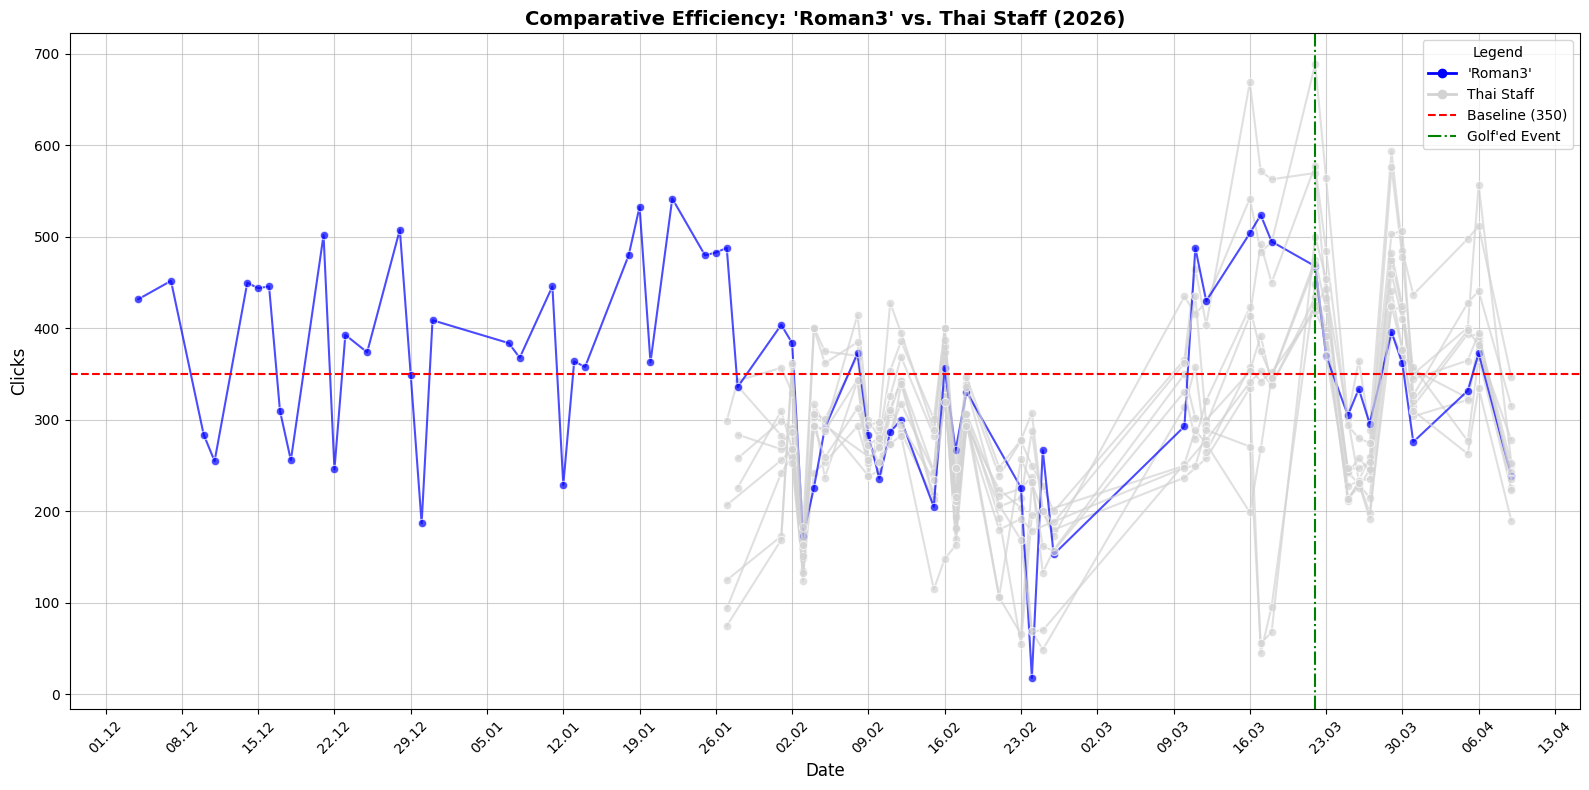

In [ ]:
import matplotlib.lines as mlines

# 1. Автоматически определяем тайские имена (все капсом), исключая SAVA3
# Теперь SAVA3 вообще не попадет в выборку
thai_staff_names = [name for name in df_latest_daily_version['name'].unique()
                    if isinstance(name, str) and name.isupper() and name != 'SAVA3']

# 2. Формируем список для фильтрации: только Roman3 и тайцы
combined_names_to_plot = list(set(thai_staff_names + ['Roman3']))

# 3. Фильтруем данные за 2026 год
multi_name_df_thai_caps = df_latest_daily_version[
    (df_latest_daily_version['name'].isin(combined_names_to_plot)) &
    (df_latest_daily_version['date'] >= '2025-12-01')
].sort_values(by=['name', 'date'])

if not multi_name_df_thai_caps.empty:
    plt.figure(figsize=(16, 8))

    # Цветовая схема: Roman3 - синий, остальные (тайцы) - светло-серый
    custom_palette_mapping = {name: 'lightgrey' for name in multi_name_df_thai_caps['name'].unique()}
    if 'Roman3' in custom_palette_mapping:
        custom_palette_mapping['Roman3'] = 'blue'

    sns.lineplot(x='date', y='clicks', hue='name', data=multi_name_df_thai_caps,
                 marker='o', palette=custom_palette_mapping, alpha=0.7)

    # --- ЕДИНЫЙ ФОРМАТ СЕТКИ ---
    plt.gca().xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO, interval=1))
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d.%m'))

    # Линии Baseline и Событий
    plt.axhline(y=350, color='r', linestyle='--', label='Baseline (350 clicks)')
    plt.axvline(x=pd.to_datetime('2026-03-22'), color='g', linestyle='-.', label="Golf'ed (March 22, 2026)")

    plt.title("Comparative Efficiency: 'Roman3' vs. Thai Staff (2026)", fontsize=14, fontweight='bold')
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Clicks', fontsize=12)

    # Оформление сетки
    plt.grid(True, which='major', linestyle='-', alpha=0.6)
    plt.grid(True, which='minor', linestyle=':', alpha=0.3)
    plt.xticks(rotation=45)

    # --- Ручное создание легенды ---
    legend_elements = []

    # Roman3
    if 'Roman3' in multi_name_df_thai_caps['name'].unique():
        legend_elements.append(mlines.Line2D([0], [0], color='blue', lw=2, marker='o', label="'Roman3'"))

    # Группа тайцев
    legend_elements.append(mlines.Line2D([0], [0], color='lightgrey', lw=2, marker='o', label='Thai Staff'))

    # Технические линии
    legend_elements.append(mlines.Line2D([0], [0], color='r', linestyle='--', label='Baseline (350)'))
    legend_elements.append(mlines.Line2D([0], [0], color='g', linestyle='-.', label="Golf'ed Event"))

    plt.legend(handles=legend_elements, title='Legend')

    plt.tight_layout()
    plt.show()
else:
    print("Данных для анализа не найдено.")

### 6. Overall Performance Distribution & Average Ranking

A ranking of all employees by their average click count. 'Roman3' is highlighted to show his standing relative to the company-wide 350-click baseline.

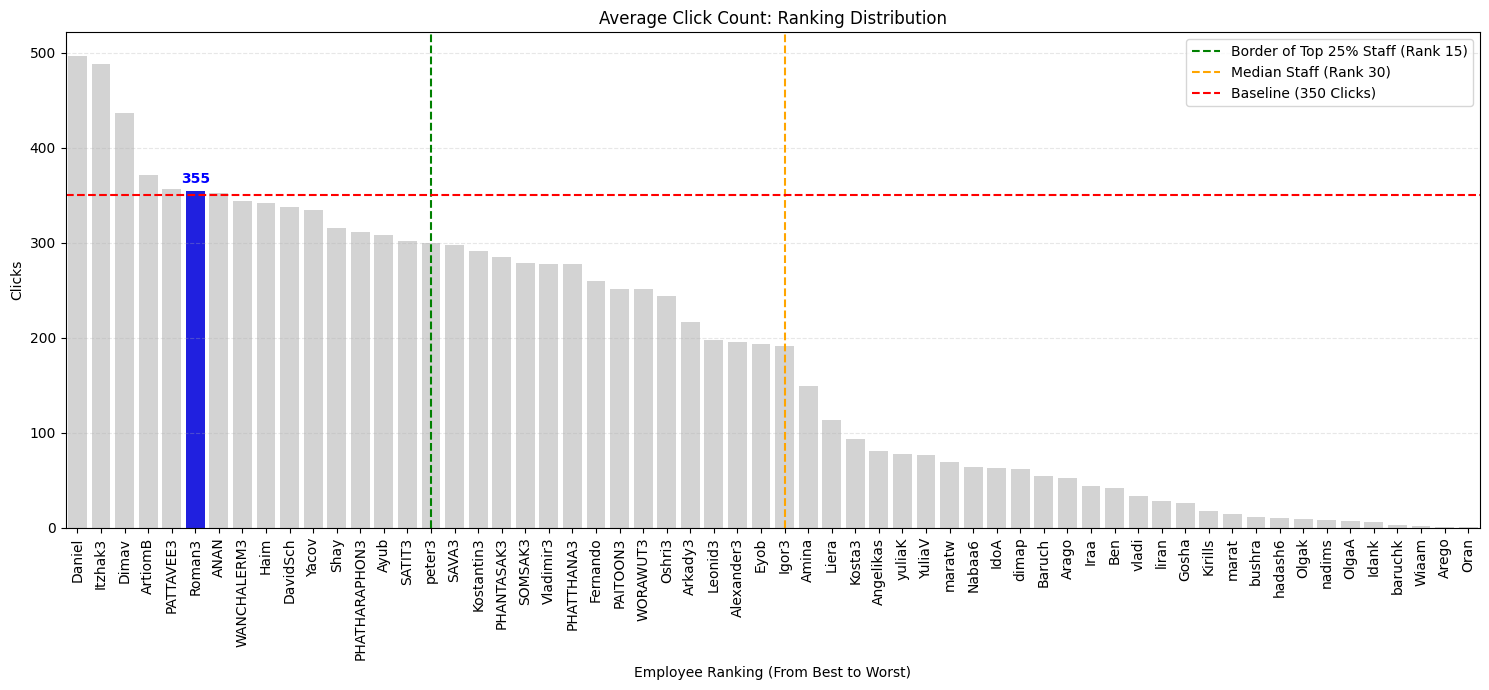

In [ ]:
# Фильтруем данные с декабря 2025
df_2026 = df_latest_daily_version[df_latest_daily_version['date'] >= '2025-12-01'].copy()

# Группируем по имени и вычисляем среднее количество кликов
average_clicks_per_name = df_2026.groupby('name')['clicks'].mean().reset_index()

# Сортируем от большего к меньшему (твой рейтинг)
average_clicks_per_name = average_clicks_per_name.sort_values(by='clicks', ascending=False).reset_index(drop=True)

# --- РАСЧЕТ КВАРТИЛЕЙ ПО КОЛИЧЕСТВУ СОТРУДНИКОВ ---
total_staff = len(average_clicks_per_name)
top_25_percent_rank = int(total_staff * 0.25)
top_50_percent_rank = int(total_staff * 0.50)

plt.figure(figsize=(15, 7))

# Цвета: 'Roman3' — синий, остальные — серые
colors = ['blue' if name == 'Roman3' else 'lightgrey' for name in average_clicks_per_name['name']]

sns.barplot(x='name', y='clicks', data=average_clicks_per_name, hue='name', palette=colors, legend=False)

# Вертикальные линии, разделяющие СОТРУДНИКОВ на группы
plt.axvline(x=top_25_percent_rank, color='green', linestyle='--', label=f'Border of Top 25% Staff (Rank {top_25_percent_rank})')
plt.axvline(x=top_50_percent_rank, color='orange', linestyle='--', label='Median Staff (Rank ' + str(top_50_percent_rank) + ')')

# Горизонтальная линия Baseline
plt.axhline(y=350, color='r', linestyle='--', label='Baseline (350 Clicks)')

plt.title('Average Click Count: Ranking Distribution')
plt.xlabel('Employee Ranking (From Best to Worst)')
plt.ylabel('Clicks')
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Метка для Roman3
roman3_avg_clicks = average_clicks_per_name[average_clicks_per_name['name'] == 'Roman3']['clicks'].iloc[0]
x_roman3 = list(average_clicks_per_name['name']).index('Roman3')
plt.text(x_roman3, roman3_avg_clicks + 5, f'{roman3_avg_clicks:.0f}', ha='center', va='bottom', color='blue', fontweight='bold')

plt.legend()
plt.tight_layout()
plt.show()

### 7. 'Roman3' Daily Output vs. Company Average

A day-by-day comparison showing whether 'Roman3' performed above or below the overall team average on any given date.

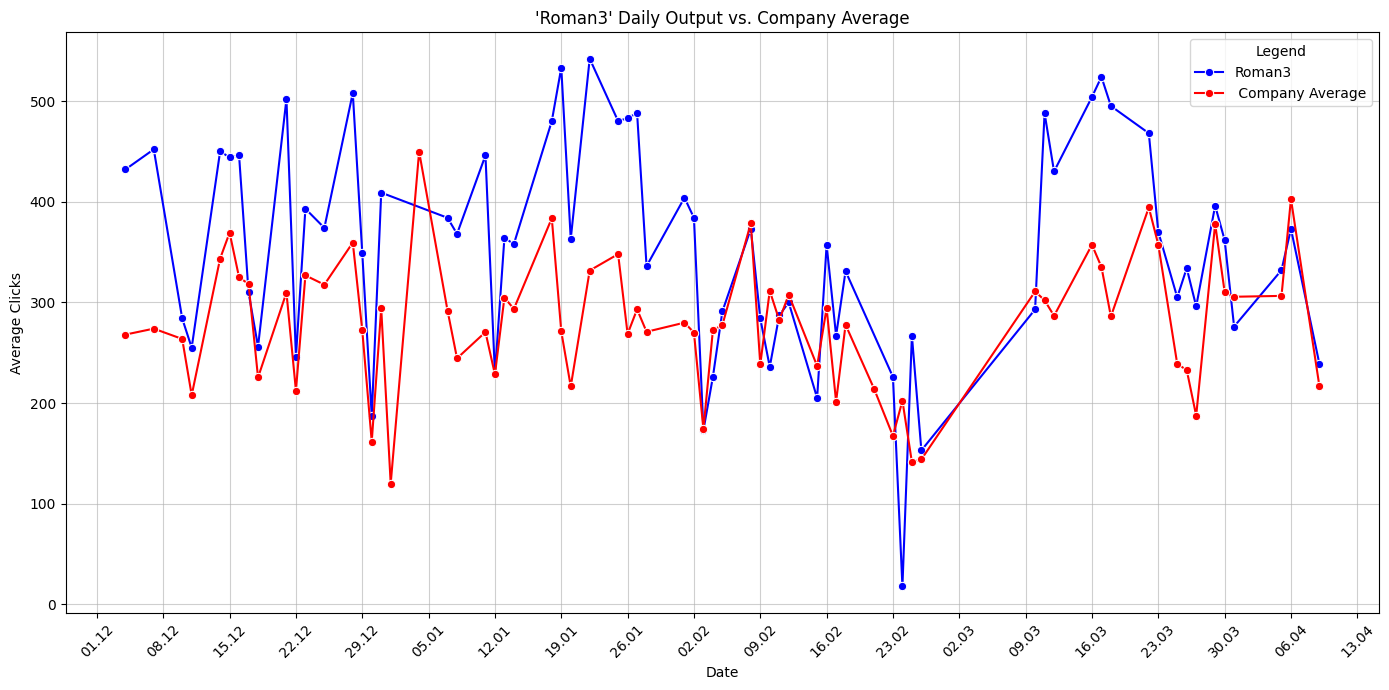

In [ ]:
# Фильтруем данные для Roman3 с декабря 2025
roman3_2026_df = df_latest_daily_version[
    (df_latest_daily_version['name'] == 'Roman3') &
    (df_latest_daily_version['date'] >= '2025-12-01')
].copy()

# Группируем по дням и вычисляем среднее количество кликов для Roman3
roman3_average_clicks_per_day = roman3_2026_df.groupby('date')['clicks'].mean().reset_index()
roman3_average_clicks_per_day['type'] = 'Roman3'

# Извлекаем данные с декабря 2025 для общего среднего
df_2026_daily_avg = df_latest_daily_version[df_latest_daily_version['date'] >= '2025-12-01'].copy()

# Группируем по дням и вычисляем общее среднее количество кликов
overall_average_clicks_per_day = df_2026_daily_avg.groupby('date')['clicks'].mean().reset_index()
overall_average_clicks_per_day['type'] = ' Company Average'

# Объединяем данные для построения графика
comparison_daily_df = pd.concat([
    roman3_average_clicks_per_day[['date', 'clicks', 'type']],
    overall_average_clicks_per_day[['date', 'clicks', 'type']]
])

plt.figure(figsize=(14, 7))
sns.lineplot(x='date', y='clicks', hue='type', data=comparison_daily_df, marker='o', palette={'Roman3': 'blue', ' Company Average': 'red'})

# --- ЕДИНЫЙ ФОРМАТ СЕТКИ ---
plt.gca().xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO, interval=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d.%m'))

plt.title("'Roman3' Daily Output vs. Company Average")
plt.xlabel('Date')
plt.ylabel('Average Clicks')

# Сетка по стандарту
plt.grid(True, which='major', linestyle='-', alpha=0.6)
plt.grid(True, which='minor', linestyle=':', alpha=0.3)

plt.xticks(rotation=45)
plt.legend(title='Legend')
plt.tight_layout()
plt.show()